<h1>NAO Index</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import scipy

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats, timeutil

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'cpc_ics'

In [4]:
ufs_var = 'slp'
era5_var = 'mean_sea_level_pressure'

In [5]:
time_range = ("1994-01-01", "2020-12-31T23")
initmonths = (5,11)

In [6]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

<h5>Get data readers</h5>

In [7]:
ufs_data_reader = dr.getDataReader(datasource='UFS',
                                   #filename=f"experiments/phase_1/{ufs_experiment}/atm_monthly.zarr",
                                   experiment=ufs_experiment,
                                   model='atm')

era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/cpc_ics/atm_monthly.zarr
No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [8]:
ufs_data_reader.describe(ufs_var)


Variable: slp
Dimensions: ('init', 'lead', 'member', 'lat', 'lon')
Shape: (60, 12, 11, 181, 360)
Attributes:
  - long_name: Pressure reduced to MSL
  - units: Pa


In [9]:
era5_data_reader.describe(era5_var)


Variable: mean_sea_level_pressure
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Mean sea level pressure
  - short_name: msl
  - standard_name: air_pressure_at_mean_sea_level
  - units: Pa


<h5>Get the monthly climatology for nino 3.4</h5>

In [10]:
ufs_ds_1 = ufs_data_reader.retrieve(var=ufs_var,
                                    time=time_range,
                                    initmonths=initmonths,
                                    lat=region_1['latmin'],
                                    lon=region_1['lonmin'],
                                    ens_avg=True).load()  # load

ufs_ds_2 = ufs_data_reader.retrieve(var=ufs_var,
                                    time=time_range,
                                    initmonths=initmonths,
                                    lat=region_2['latmin'],
                                    lon=region_2['lonmin'],
                                    ens_avg=True).load()  # load

Taking Ensemble Average
Taking Ensemble Average


<h5>Get the corresponding ERA5 data</h5>

In [11]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'])

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'])

In [12]:
# Ensure that temporal domains perfectly match.
era5_ds_1 = timeutil.match_time_to_leads(verif_ds=era5_ds_1,
                                         ufs_ds=ufs_ds_1).load()  # load

era5_ds_2 = timeutil.match_time_to_leads(verif_ds=era5_ds_2,
                                         ufs_ds=ufs_ds_2).load()  # load

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [13]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=False)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=False)

In [14]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [15]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_var], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_var], stats=ufs_stats_2)

In [16]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [17]:
ufs_da_1 = ufs_da_1.squeeze(['lat', 'lon'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['lat', 'lon'])
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])

In [18]:
ufs_ds_nao = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_nao = (era5_da_2 - era5_da_1).to_dataset()

<h2>Calculate Anomaly Correlation Coefficient</h2>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'                                                                               
plt.rcParams['font.sans-serif'] = ['Cantarell'] + plt.rcParams['font.sans-serif']                                        
plt.rcParams['font.size'] = 14

In [20]:
all_inits = list(ufs_ds_nao.init.values)
all_leads = list(ufs_ds_nao.lead.values)

all_init_months = list(set([pd.to_datetime(this_init).month for this_init in all_inits]))

# Initialize accs
accs = dict.fromkeys(all_init_months)
ps = dict.fromkeys(all_init_months)

# Calculate acc per initmonth per lead
for i in range(len(all_init_months)):  
    this_init_month = all_init_months[i]
    these_inits = [this_init for this_init in all_inits if pd.to_datetime(this_init).month == this_init_month]
    
    accs_for_this_init_month = []
    p_for_this_init_month = []
    
    for j in range(len(all_leads)):     
        this_lead = all_leads[j]   
        
        # Get UFS 1-d array
        all_ufs_values = [ufs_ds_nao.sel(init=this_init, lead=this_lead)[ufs_var].values.item()
                          for this_init in these_inits]
        
        # Get VERIF 1-d array (forward project)
        all_verif_values = []
        for this_init in these_inits:
            this_time = timeutil.time_offset(freq_unit='MS',
                                             init=this_init,
                                             lead=this_lead,
                                             step=np.timedelta64(30, 'D'),
                                             direction='forward')
            
            all_verif_values.append(era5_ds_nao.sel(time=this_time)[era5_var].values.item())
        
        if len(all_ufs_values) != len(all_verif_values):
            msg = f'Differing lengths for ufs values {len(all_ufs_values)} and verif values {len(all_verif_values)} trying to calculate ACC.'
            raise ValueError(msg)

#         # Covariance
#         this_covar = np.cov(m=all_ufs_values, y=all_verif_values, ddof=0)
        
#         # Standard Deviations
#         ufs_std = np.std(a=all_ufs_values, ddof=0)
#         verif_std = np.std(a=all_verif_values, ddof=0)
        
#         # Anomaly Correlation Coefficient
#         this_acc = this_covar / (ufs_std * verif_std)
        
#         # Extract acc value from matrix
#         this_acc_value = this_acc[0, 1]
        
#         # Append results for this lead to list of values
#         accs_for_this_init_month.append(this_acc_value)
        
        r, p_value = scipy.stats.pearsonr(all_ufs_values, all_verif_values)
        accs_for_this_init_month.append(r)
        p_for_this_init_month.append(p_value)
        
        # print(f"this init month: {this_init_month}")
        # print(f"this lead: {this_lead}")
        # print(f"Correlation: {r}")
        # print(f"P-value: {p_value}")
        # print("")
    
    # Store results
    accs[this_init_month] = accs_for_this_init_month
    ps[this_init_month] = p_for_this_init_month
        

<h2>Plot ACC</h2>

In [21]:
# Create skill mesh for plotting, insert values
skill_mesh = np.full((12, 12), np.nan)
p_mesh = np.full((12, 12), np.nan)

for this_acc in accs.keys():
    skill_mesh[:, this_acc] = accs[this_acc]
    p_mesh[:, this_acc] = ps[this_acc]

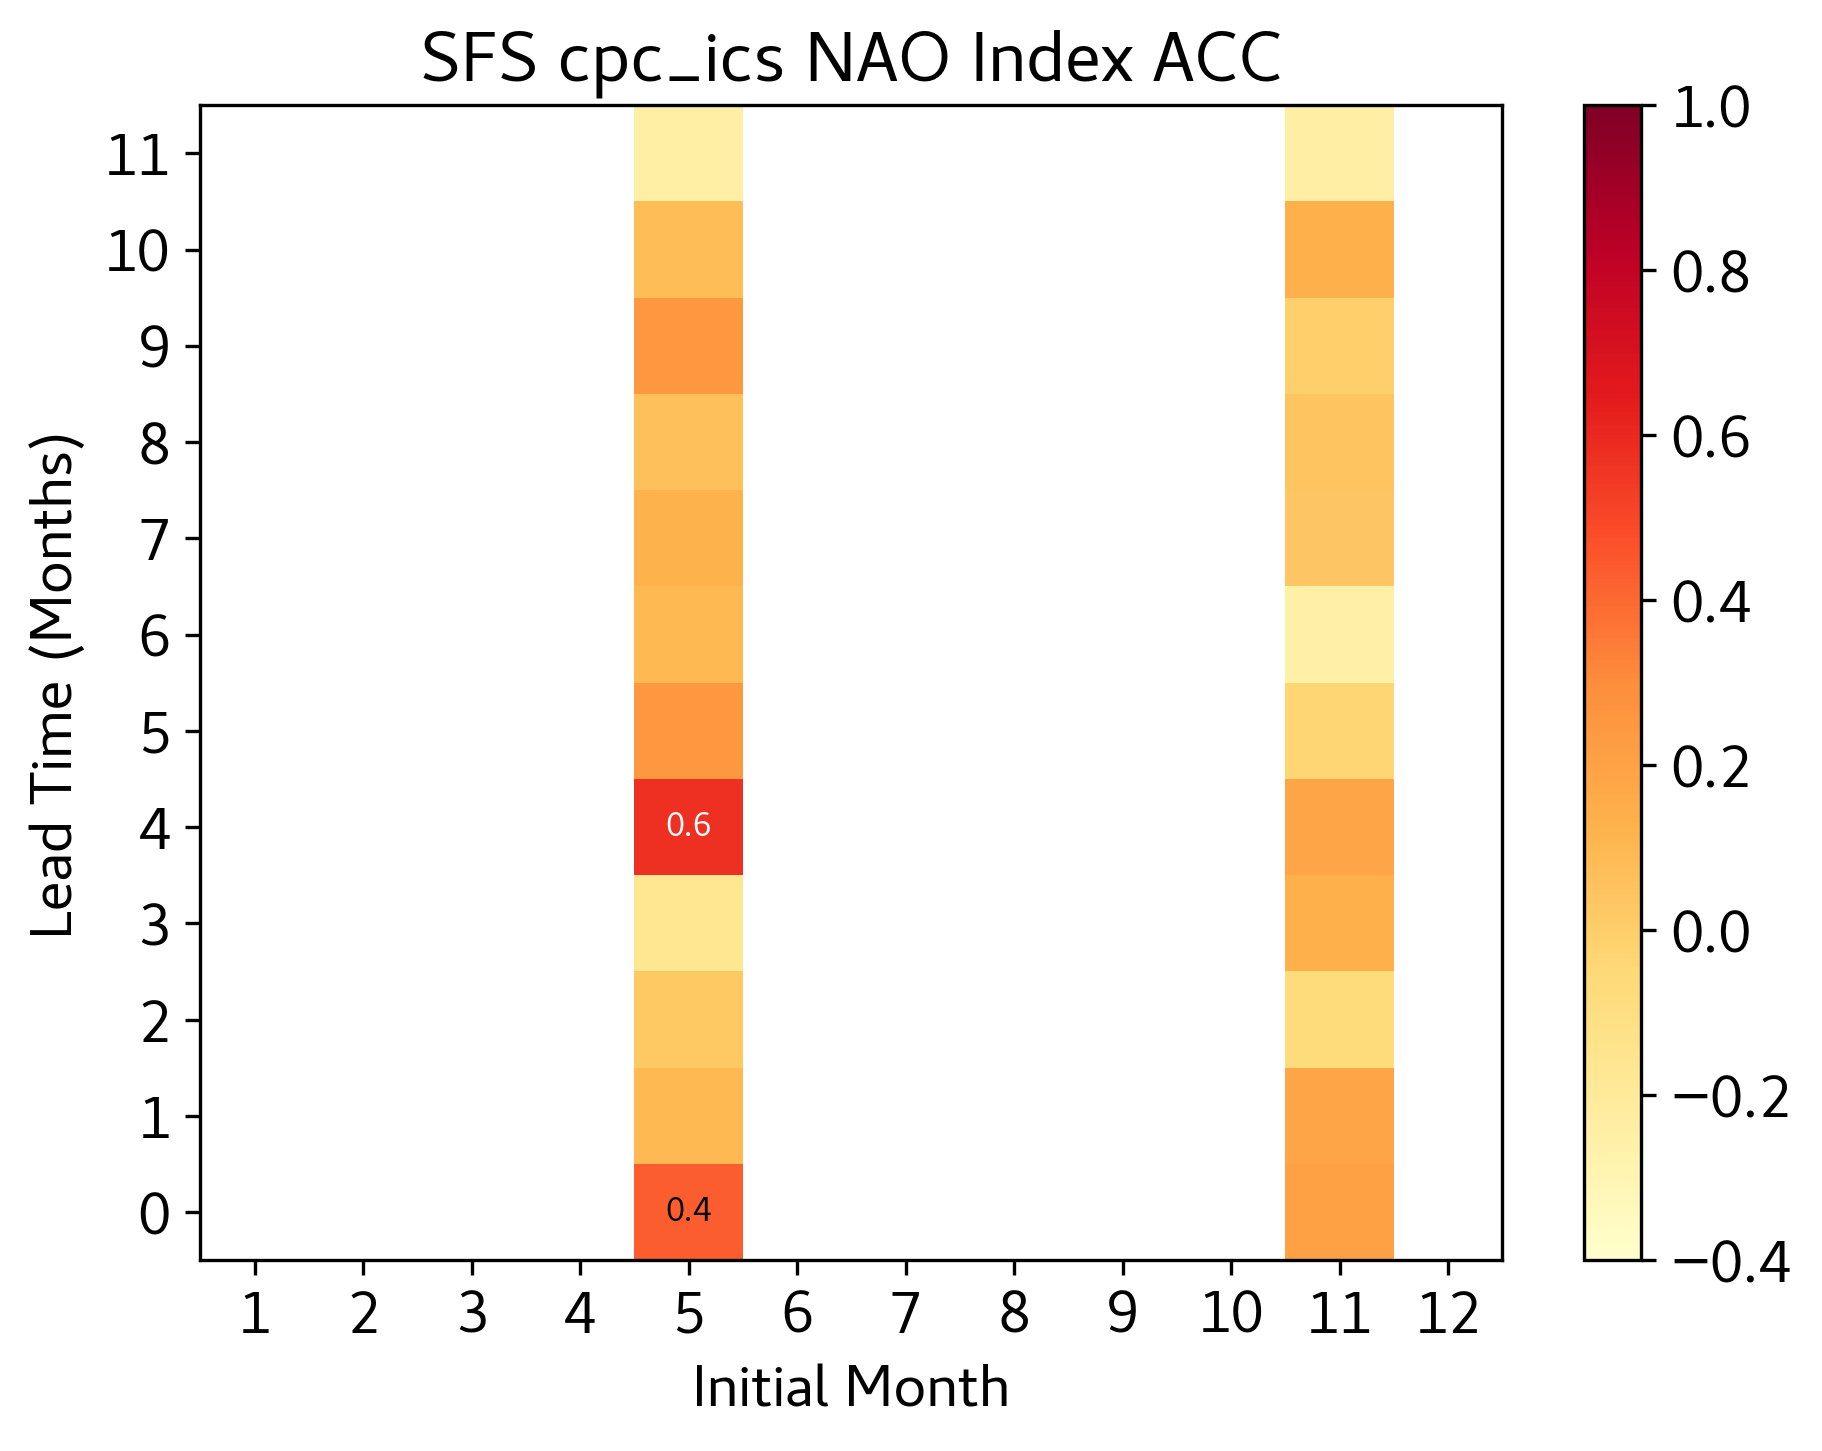

In [22]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

pcm = ax.pcolormesh(skill_mesh, cmap=plt.cm.YlOrRd, vmin=-0.4, vmax=1.0)
fig.colorbar(pcm, ax=ax)

# Define tick marks
# x
xtick_values = np.arange(1, 14) + 0.5
xtick_labels = [str(this) for this in np.arange(1, 14)]

# y
ytick_values = np.arange(0, 12) + 0.5
ytick_labels = [str(this) for this in np.arange(0, 12)]

# Set ticks
plt.xticks(ticks=xtick_values, labels=xtick_labels)
plt.yticks(ticks=ytick_values, labels=ytick_labels)

# Set range
plt.xlim(1, 13)

plt.title(f"SFS {ufs_experiment} NAO Index ACC")
plt.xlabel("Initial Month")
plt.ylabel("Lead Time (Months)")

## Add value labels

alpha = 0.05

for i in range(skill_mesh.shape[0]):
    for j in range(skill_mesh.shape[1]):
        
        if p_mesh[i][j] <= alpha:
        
            # Center the text in the middle of the cell
            text_x = j + 0.5
            text_y = i + 0.5

            # Calculate text color dynamically (white for dark backgrounds, black for light)
            val = skill_mesh[i, j]
            bg_color = pcm.cmap(pcm.norm(val))
            luminance = 0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2]
            text_color = 'white' if luminance < 0.5 else 'black'

            if not np.isnan(val):       
                ax.text(text_x, text_y, f"{val:.1f}", 
                        ha='center', va='center', 
                        color=text_color, fontweight='light', fontsize=8)